In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1/a. Class 6-sided die
class Die:
    def __init__(self):
        # Constructor
        pass
        
    def __del__(self):
        # Destructor (Rarely used in modern Python, but good for memory cleanup)
        pass
        
    def roll(self):
        return np.random.randint(1, 7)

# 1/b. Class Bash with 3 parallel dice
class Bash:
    def __init__(self):
        self.dice = (Die(), Die(), Die()) # Tuple of 3 objects
        
    def roll_parallel(self):
        # A direct map to avoid writing a traditional loop
        return np.array(list(map(lambda d: d.roll(), self.dice)))

# Test the class
my_bash = Bash()
print("Single OOP Bash Roll:", my_bash.roll_parallel())

Single OOP Bash Roll: [2 3 3]


In [2]:
GAMES = 50
MAX_ROUNDS = 30 # 30 rounds is statistically more than enough to reach 5 points

# Shape: (50 games, 30 rounds, 2 players, 3 dice)
rolls = np.random.randint(1, 7, size=(GAMES, MAX_ROUNDS, 2, 3))

# Calculate sums across the dice (axis 3). New shape: (50, 30, 2)
sums = rolls.sum(axis=3)

# Check for the automatic win condition (1, 1, 1). New shape: (50, 30, 2)
is_111 = np.all(rolls == 1, axis=3)

# Initialize points tensor: (50, 30, 2)
pts = np.zeros((GAMES, MAX_ROUNDS, 2))

# Rule 1 & 3: Higher sum gets 1, Tie gets 0.5
p1_wins_sum = sums[:, :, 0] > sums[:, :, 1]
p2_wins_sum = sums[:, :, 1] > sums[:, :, 0]
ties = sums[:, :, 0] == sums[:, :, 1]

pts[:, :, 0] = np.where(p1_wins_sum, 1.0, np.where(ties, 0.5, 0.0))
pts[:, :, 1] = np.where(p2_wins_sum, 1.0, np.where(ties, 0.5, 0.0))

# Rule 2: (1,1,1) Overrides
# If P1 rolls 111, P1 gets 1, P2 gets 0
pts[:, :, 0] = np.where(is_111[:, :, 0], 1.0, pts[:, :, 0])
pts[:, :, 1] = np.where(is_111[:, :, 0], 0.0, pts[:, :, 1])
# If P2 rolls 111, P2 gets 1, P1 gets 0 (unless P1 also rolled 111)
pts[:, :, 1] = np.where(is_111[:, :, 1], 1.0, pts[:, :, 1])
pts[:, :, 0] = np.where(is_111[:, :, 1] & ~is_111[:, :, 0], 0.0, pts[:, :, 0])

# Cumulative points across rounds (axis 1)
cum_pts = np.cumsum(pts, axis=1)

# Game End Condition: Someone hits >= 5 AND it's not a tie
valid_win = (cum_pts[:, :, 0] >= 5) | (cum_pts[:, :, 1] >= 5)
not_tie = cum_pts[:, :, 0] != cum_pts[:, :, 1]
win_mask = valid_win & not_tie

# np.argmax finds the index of the FIRST round where the win condition is True
win_rounds = np.argmax(win_mask, axis=1)

# Extract the final scores using the winning round indices
p1_final = cum_pts[np.arange(GAMES), win_rounds, 0]
p2_final = cum_pts[np.arange(GAMES), win_rounds, 1]

# 4/a: Probability of P1 winning
p1_wins = np.sum(p1_final > p2_final)
prob_p1_win = p1_wins / GAMES
print(f"Player 1 won {p1_wins} out of {GAMES} games.")
print(f"Probability of Player 1 winning: {prob_p1_win:.2f}")

Player 1 won 28 out of 50 games.
Probability of Player 1 winning: 0.56


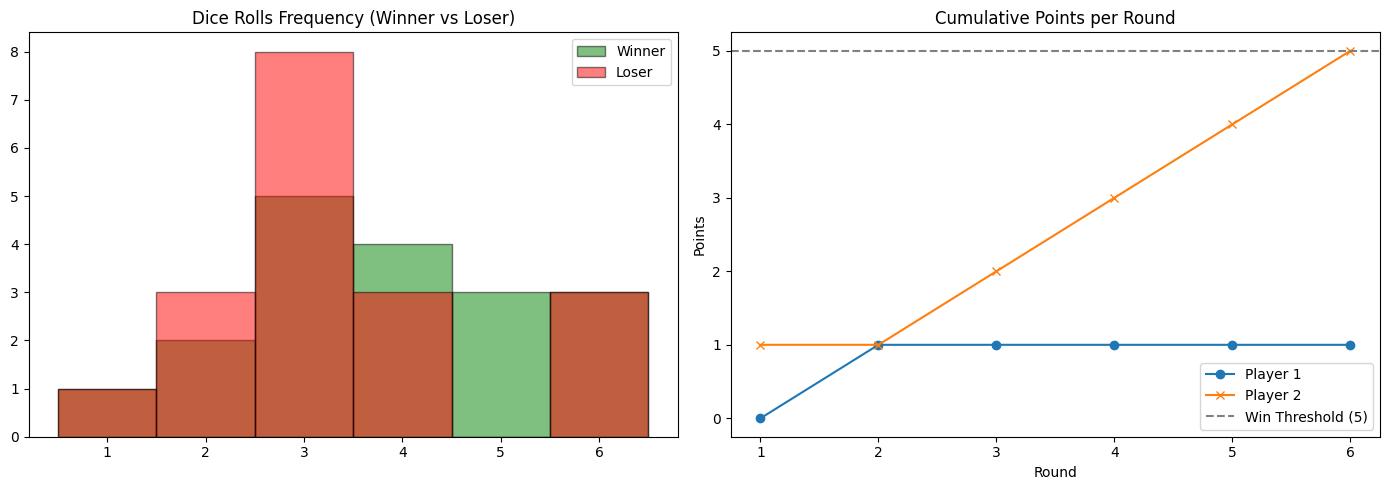

In [3]:
game_idx = 0
rounds_played = win_rounds[game_idx] + 1 # +1 because indices are 0-based

# Extract data for this specific game
game_rolls = rolls[game_idx, :rounds_played] # Shape: (rounds, 2, 3)
game_cum_pts = cum_pts[game_idx, :rounds_played] # Shape: (rounds, 2)

# Determine who won this specific game
winner_idx = 0 if p1_final[game_idx] > p2_final[game_idx] else 1
loser_idx = 1 - winner_idx

winner_rolls = game_rolls[:, winner_idx, :].flatten()
loser_rolls = game_rolls[:, loser_idx, :].flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 3/a. Histogram of rolls for Winner vs Loser
axes[0].hist(winner_rolls, bins=np.arange(1, 8)-0.5, alpha=0.5, label='Winner', color='green', edgecolor='black')
axes[0].hist(loser_rolls, bins=np.arange(1, 8)-0.5, alpha=0.5, label='Loser', color='red', edgecolor='black')
axes[0].set_title('Dice Rolls Frequency (Winner vs Loser)')
axes[0].set_xticks(range(1, 7))
axes[0].legend()

# 3/b. Line chart for cumulative points
axes[1].plot(range(1, rounds_played + 1), game_cum_pts[:, 0], marker='o', label='Player 1')
axes[1].plot(range(1, rounds_played + 1), game_cum_pts[:, 1], marker='x', label='Player 2')
axes[1].axhline(y=5, color='gray', linestyle='--', label='Win Threshold (5)')
axes[1].set_title('Cumulative Points per Round')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('Points')
axes[1].legend()

plt.tight_layout()
plt.show()

In [4]:
# Flatten all rolls from all 50 games to get a massive sample size
all_individual_rolls = rolls[:, :, :, :].flatten()
all_sums = sums.flatten()

# 1. Chi-Square Test for Individual Rolls (Checking for Uniformity)
# Expected frequency is the total rolls divided by 6 sides
observed_freq, _ = np.histogram(all_individual_rolls, bins=np.arange(1, 8))
expected_freq = np.full(6, len(all_individual_rolls) / 6)
chi_stat, chi_p = stats.chisquare(f_obs=observed_freq, f_exp=expected_freq)

print("--- Distribution of Individual Rolls (Uniformity) ---")
print(f"Chi-Square p-value: {chi_p:.4f}")
if chi_p < 0.05:
    print("Result: The dice are NOT fair (Uniform distribution rejected).")
else:
    print("Result: The dice appear fair (Uniform distribution holds).")

# 2. Shapiro-Wilk Test for the Sum of 3 Dice (Checking for Normality)
# Note: Shapiro-Wilk struggles with massive arrays, so we sample 1000 sums
sample_sums = np.random.choice(all_sums, 1000, replace=False)
shapiro_stat, shapiro_p = stats.shapiro(sample_sums)

print("\n--- Distribution of the Sum of 3 Dice (Normality) ---")
print(f"Shapiro-Wilk p-value: {shapiro_p:.4f}")
if shapiro_p < 0.05:
    print("Result: Not perfectly normal (Reject Null). While it looks bell-shaped, the discrete nature of dice fails strict normality tests.")
else:
    print("Result: The distribution is Normally distributed.")

--- Distribution of Individual Rolls (Uniformity) ---
Chi-Square p-value: 0.4722
Result: The dice appear fair (Uniform distribution holds).

--- Distribution of the Sum of 3 Dice (Normality) ---
Shapiro-Wilk p-value: 0.0000
Result: Not perfectly normal (Reject Null). While it looks bell-shaped, the discrete nature of dice fails strict normality tests.
